# Analysis of parking occupancy
Compared to archive: Take base occupancy as parking supply and analyse the relative overshoot during the policy case.

In [8]:
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import numpy as np
%config InlineBackend.figure_format = 'retina'

base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended-10pct/"
base_parking = pd.read_csv(base_path + "parking_occupancy.csv.zst")

policy_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct-deparking-p20_d0_i0_max1000/"
policy_parking = pd.read_csv("%sITERS/it.500/berlin-v6.4.500.parking_occupancy.csv.zst" % policy_path)

policy_base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct_walkPlanFix/"
policy_base_parking = pd.read_csv("%sITERS/it.500/berlin-v6.4.500.parking_occupancy.csv.zst" % policy_base_path)

pct = 0.1


df_links = pd.read_csv(
    policy_path + "berlin-v6.4.output_links.csv.zst",
    sep=";",
    compression="zstd",
    dtype={"link": "string"},
    low_memory=False,
)

links = gpd.GeoDataFrame(
    df_links[~df_links["link"].str.contains("pt_")],
    geometry=gpd.GeoSeries.from_wkt(df_links["geometry"], crs="EPSG:25832"),
)
links

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,allowed_speed,maxInflowUsedInQsim,name,parkingSpots,speed_factor,restricted_lanes,hbefa_road_type,storageCapacityUsedInQsim,type,geometry
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,0,...,13.89,1053.102038,Lindenweg,1.000000,4.634,NaN,URB/Access/50,NaN,highway.residential,"LINESTRING (796573.1 5797464.9, 796580.93 5797..."
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,commercial_goods_car,freight,truck",0,0,...,2.78,760.043646,Lilli-Henoch-Straße,6.000000,2.554,NaN,URB/Access/30,0.821848,highway.living_street,"LINESTRING (800578.77 5830375.13, 800629.32 58..."
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,1,...,13.89,1383.203395,Dorfstraße,1.000000,9.344,NaN,URB/Local/50,4.084962,highway.tertiary,"LINESTRING (807040 5714450.85, 806856.97 57145..."
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",119,29,...,13.89,1430.264357,Lichtenrader Straße,1.000000,10.460,NaN,URB/Access/50,2.468196,highway.unclassified,"LINESTRING (799342.3 5811143.42, 799386.89 581..."
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,commercial_goods_car,freight,truck",0,4,...,8.33,1262.515118,Roseggerstraße,2.000000,7.133,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (802003.09 5823888.17, 801962.85 58..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,5.56,873.518677,NaN,0.282267,3.231,NaN,URB/Access/30,0.538347,highway.cycleway,"LINESTRING (809649.3 5829245.86, 809633.22 582..."
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,5.56,1143.336874,NaN,2.203467,5.561,NaN,URB/Access/30,2.721241,highway.path,"LINESTRING (813176.2 5831254, 813018.57 583120..."
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,5.56,1148.936170,NaN,1.960667,5.625,NaN,URB/Access/30,2.409587,highway.path,"LINESTRING (813018.57 5831208.39, 812877.65 58..."
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",31,3,...,8.33,1264.143168,Goethestraße,2.343467,7.158,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (801940.36 5803217.47, 802026.89 58..."


In [9]:
bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson").to_crs(epsg=3857)
umweltzone = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/umweltzone/Umweltzone_Berlin.shp").to_crs(epsg=3857)
bezirke_outline = bezirke.union_all()

In [27]:
def add_location_column(links, umweltzone, bezirke):
    """
    Adds a 'location' column to links GeoDataFrame.

    Rules:
    - "IR": geometry within umweltzone
    - "OR": geometry within bezirke but NOT within umweltzone
    - "BRA": everywhere else
    """

    # Ensure same CRS
    if links.crs != umweltzone.crs:
        umweltzone = umweltzone.to_crs(links.crs)

    if links.crs != bezirke.crs:
        bezirke = bezirke.to_crs(links.crs)

    # Merge geometries into single polygons
    umwelt_union = umweltzone.union_all()
    bezirke_union = bezirke.union_all()

    # Spatial checks
    in_umweltzone = links.geometry.within(umwelt_union)
    in_bezirke = links.geometry.within(bezirke_union)

    # Assign labels
    links = links.copy()

    links["location"] = np.select(
        [
            in_umweltzone,
            in_bezirke & ~in_umweltzone
        ],
        [
            "IR",
            "OR"
        ],
        default="BRA"
    )

    return links

links = add_location_column(links, umweltzone, bezirke)

## Parking Cost

In [30]:
import numpy as np
import pandas as pd

def merge_links_parking(links: pd.DataFrame, parking: pd.DataFrame, location=("IR", "OR")) -> pd.DataFrame:
    if isinstance(location, str):
        location = {location}
    else:
        location = set(location)

    df = links.merge(parking, left_on="link", right_on="linkId", suffixes=("_links", "_occupancy"))
    df = df[df["modes"].str.contains(r"\bcar\b", na=False)]
    df = df[df["location"].isin(location)]

    df["occupancy_diff"] = df["occupancy"] - df["parkingSpots"]
    df["relative_overshoot"] = df["occupancy_diff"] / df["parkingSpots"]
    df["to_time"] = df["to_time"].replace(np.inf, 36 * 3600)
    df["delta_time_s"] = df["to_time"] - df["from_time"]
    df["overshoot_veh_h"] = df["delta_time_s"] / 3600 * df["occupancy_diff"]
    df["capacity_veh_h"] = df["delta_time_s"] / 3600 * df["parkingSpots"]

    return df

In [35]:
def print_violation_share(df_base_policy, df_policy, where):
    print(f"BASE POLICY: Relative oversubscribed spot hours {where} wide: {df_base_policy["overshoot_veh_h"].clip(lower=0).sum() / df_base_policy["capacity_veh_h"].sum()}")
    print(f"POLICY: Relative oversubscribed spot hours {where} wide: {df_policy["overshoot_veh_h"].clip(lower=0).sum() / df_policy["capacity_veh_h"].sum()}")

In [46]:
def print_share_oversubscribed_links(df: pd.DataFrame):
    # group by link and keep the maximum relative_overshoot per link
    grouped = (
        df.groupby("link", as_index=False)["relative_overshoot"]
        .max()
    )

    # share of links with relative_overshoot > 0
    share_positive = (grouped["relative_overshoot"] > 0).mean()

    print(f"Share of links with relative_overshoot > 0: {share_positive:.2%}")


In [50]:
policy_base_x_links = merge_links_parking(links, policy_base_parking)
policy_x_links = merge_links_parking(links, policy_parking)
print_violation_share(policy_base_x_links, policy_x_links, "Berlin")

# print_share_oversubscribed_links(policy_base_x_links)
# print_share_oversubscribed_links(policy_x_links)


BASE POLICY: Relative oversubscribed spot hours Berlin wide: 0.025751392547195173
POLICY: Relative oversubscribed spot hours Berlin wide: 0.00022760939509691637
Share of links with relative_overshoot > 0: 8.68%
Share of links with relative_overshoot > 0: 5.17%


In [38]:
policy_base_x_links_ir = merge_links_parking(links, policy_base_parking, location="IR")
policy_x_links_ir = merge_links_parking(links, policy_parking, location="IR")
print_violation_share(policy_base_x_links_ir, policy_x_links_ir, "Berlin IR")

BASE POLICY: Relative oversubscribed spot hours Berlin IR wide: 0.6790639274464535
POLICY: Relative oversubscribed spot hours Berlin IR wide: 0.003722926113852649


In [ ]:
# print share of links that is oversubscribed at least once per simulation

In [ ]:
# print maximum share of oversubscription

# Some other plots

In [45]:
# join base and policy on linkId.
merged = base_parking.merge(policy_parking, on="linkId", suffixes=("_base", "_policy"))
merged["occupancy_diff"] = merged["occupancy_policy"] - merged["occupancy_base"]
merged["relative_overshoot"] = merged["occupancy_diff"] / merged["occupancy_base"].replace(0,pd.NA)  # avoid division by zero, set to NA
merged

,linkId,from_time_base,to_time_base,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,15805101#0,0.0,561.0,91.18,16.0,16.0,0.0,561.0,91.18,16.0,16.0,0.0,0.0000
1,15805101#0,0.0,561.0,91.18,16.0,16.0,561.0,5971.0,91.18,15.0,16.0,-1.0,-0.0625
2,15805101#0,0.0,561.0,91.18,16.0,16.0,5971.0,13646.0,91.18,14.0,16.0,-2.0,-0.1250
3,15805101#0,0.0,561.0,91.18,16.0,16.0,13646.0,14485.0,91.18,15.0,16.0,-1.0,-0.0625
4,15805101#0,0.0,561.0,91.18,16.0,16.0,14485.0,19449.0,91.18,14.0,16.0,-2.0,-0.1250
...,...,...,...,...,...,...,...,...,...,...,...,...,...
905852,-1125022715,33837.0,35593.0,442.76,2.0,0.0,44511.0,46004.0,442.76,1.0,0.0,-1.0,-0.5000
905853,-1125022715,33837.0,35593.0,442.76,2.0,0.0,46004.0,inf,442.76,0.0,0.0,-2.0,-1.0000
905854,-1075671608,63108.0,65550.0,15.87,1.0,0.0,0.0,60954.0,15.87,0.0,0.0,-1.0,-1.0000
905855,-1075671608,63108.0,65550.0,15.87,1.0,0.0,60954.0,63414.0,15.87,1.0,0.0,0.0,0.0000


In [46]:
# join merged with links on linkId and link, keep all columns
final = links.merge(merged, left_on="link", right_on="linkId", how="left")
final_3857 = final.to_crs(epsg=3857)
final_3857["geometry"] = final_3857.geometry.simplify(2)
# final_3857["relative_overshoot"] = final_3857["relative_overshoot"]
# final_3857[final_3857["link"] == "306046325"]
final_3857

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,0,...,28.01,1.0,0.0,0.0,58221.0,28.01,0.0,0.0,-1.0,-1.0
1,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,0,...,28.01,1.0,0.0,58221.0,65875.0,28.01,1.0,0.0,0.0,0.0
2,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,0,...,28.01,1.0,0.0,65875.0,inf,28.01,0.0,0.0,-1.0,-1.0
3,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,commercial_goods_car,freight,truck",0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,1,...,223.51,1.0,1.0,0.0,19907.0,223.51,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058791,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1058792,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1058793,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1058794,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",31,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of links with relative overshoot > 4: 8
Percentiles of relative_overshoot:
0.250   -0.722222
0.500   -0.500000
0.750   -0.300000
0.900    0.000000
0.950    0.000000
0.990    0.000000
0.999    0.500000
Name: relative_overshoot, dtype: float64


<Axes: ylabel='Frequency'>

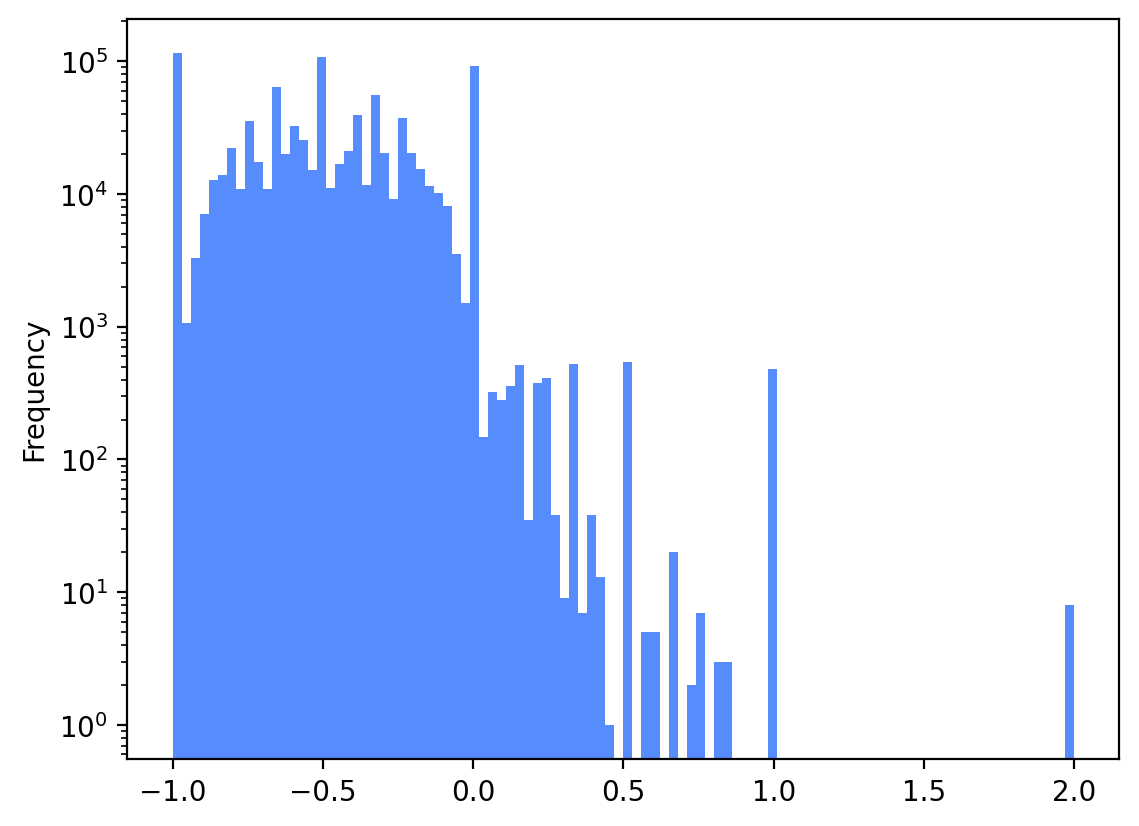

In [47]:
# count how many links have a relative_overshoot of >4
num_links_overshoot = (final_3857["relative_overshoot"] > 1).sum()
print(f"Number of links with relative overshoot > 4: {num_links_overshoot}")

# print percentiles of relative_overshoot
percentiles = final_3857["relative_overshoot"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Percentiles of relative_overshoot:")
print(percentiles)

# make a hist plot of relative_overshoot, excluding NA values and log y axis
final_3857["relative_overshoot"].dropna().plot.hist(bins=100, log=True)

<Axes: ylabel='Frequency'>

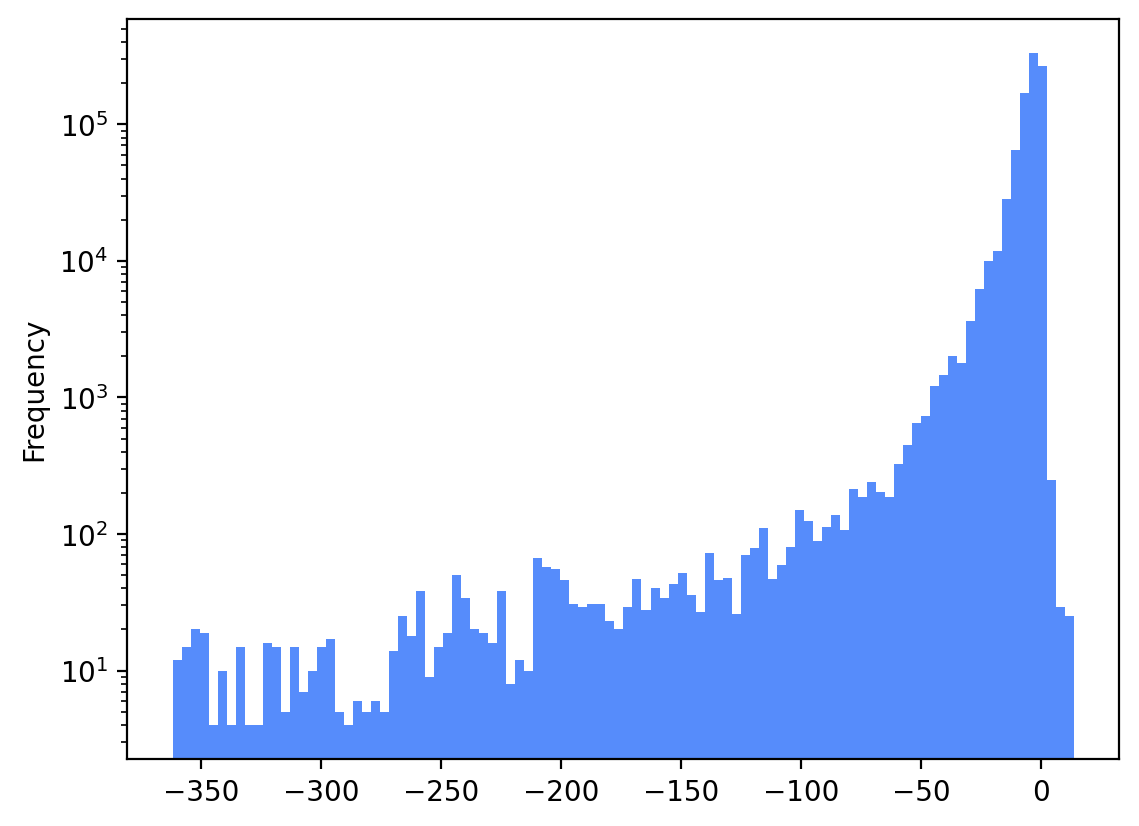

In [48]:
final_3857["occupancy_diff"].dropna().plot.hist(bins=100, log=True)

<Axes: xlabel='relative_overshoot', ylabel='occupancy_diff'>

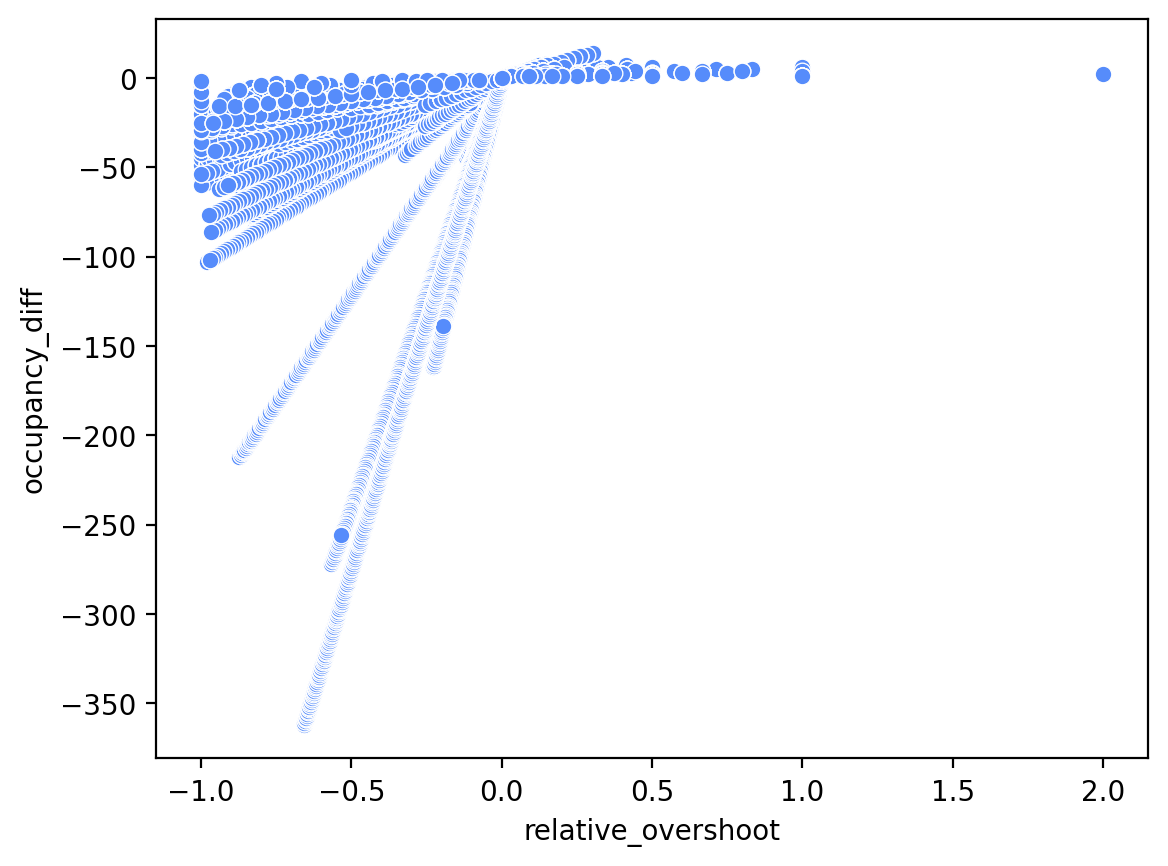

In [49]:
import seaborn as sns
sns.scatterplot(final_3857, x="relative_overshoot", y="occupancy_diff")

In [50]:
value_col = "relative_overshoot"

final_3857[value_col] = pd.to_numeric(final_3857[value_col], errors="coerce")
gdf_plot = final_3857.loc[
    final_3857[value_col].notna() & (final_3857[value_col] > 0) & (final_3857[value_col] > 1.0)
].copy()

# print row count of gdf_plot
zone = gpd.read_file('../../../../input/v6.4/umweltzone/Umweltzone_Berlin.shp')

# gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())].shape[1]
# filtered = gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())]
filtered = gdf_plot
filtered

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
124576,-128411169#1,cluster_1412637428_1418830102,1328047476,457.68,12.028,1944.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",4,32,...,457.68,1.0,0.0,55816.0,58414.0,457.68,3.0,0.0,2.0,2.0
421053,-28424312,303486463,303487537,1558.73,8.483,1619.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",20,1,...,1558.73,1.0,0.0,56759.0,56776.0,1558.73,3.0,0.0,2.0,2.0
435573,-295698185,3379905890,32681371,172.40,11.979,2053.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",647,214,...,172.40,1.0,0.0,72827.0,74028.0,172.40,3.0,1.0,2.0,2.0
449121,-30898939#0,31011926,31011900,291.09,7.171,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",4,0,...,291.09,1.0,0.0,28395.0,28902.0,291.09,3.0,1.0,2.0,2.0
736192,-779303216,7276676911,453316833,29.73,2.567,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",5,0,...,29.73,1.0,0.0,56681.0,57014.0,29.73,3.0,0.0,2.0,2.0
923930,28552785#0,243856097,310818639,227.12,9.718,4113.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",442,534,...,227.12,1.0,0.0,33334.0,34165.0,227.12,3.0,0.0,2.0,2.0
949975,333967937#0,cluster_10237995409_10237995454_1599974865_213...,cluster_10237995456_29123399,93.05,7.885,4108.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",260,134,...,93.05,1.0,0.0,60226.0,60585.0,93.05,3.0,0.0,2.0,2.0
987580,4526203#0,162369688,cluster_26747601_26747602_28096060_28096063,66.11,4.712,3380.0,4.0,"bike,car,commercial_goods_car,freight,ride,truck",462,1858,...,66.11,1.0,0.0,51158.0,51588.0,66.11,3.0,0.0,2.0,2.0


In [51]:
policy_parking_cost = pd.read_csv(policy_path + "/ITERS/it.500/berlin-v6.4.500.parking_costs.csv.zst")

cost_df = links.merge(policy_parking_cost, left_on="link", right_on="linkId", how="left")
# set all cost_df[cost] = NaN values to 0
cost_df["cost"] = cost_df["cost"].fillna(0)

cost_df = cost_df.to_crs(epsg=3857)
cost_df["geometry"] = cost_df.geometry.simplify(2)

In [52]:
# filtered_cost = cost_df[cost_df["cost"] > 0.1]
# filtered_cost = filtered_cost[filtered_cost["from_time"] == 14 * 3600]

# group cost_df by link and take largest value in cost col
filtered_cost = (
    cost_df.sort_values("cost", ascending=False)
    .drop_duplicates("link", keep="first")
)
filtered_cost = filtered_cost[filtered_cost["cost"] > 0.01]


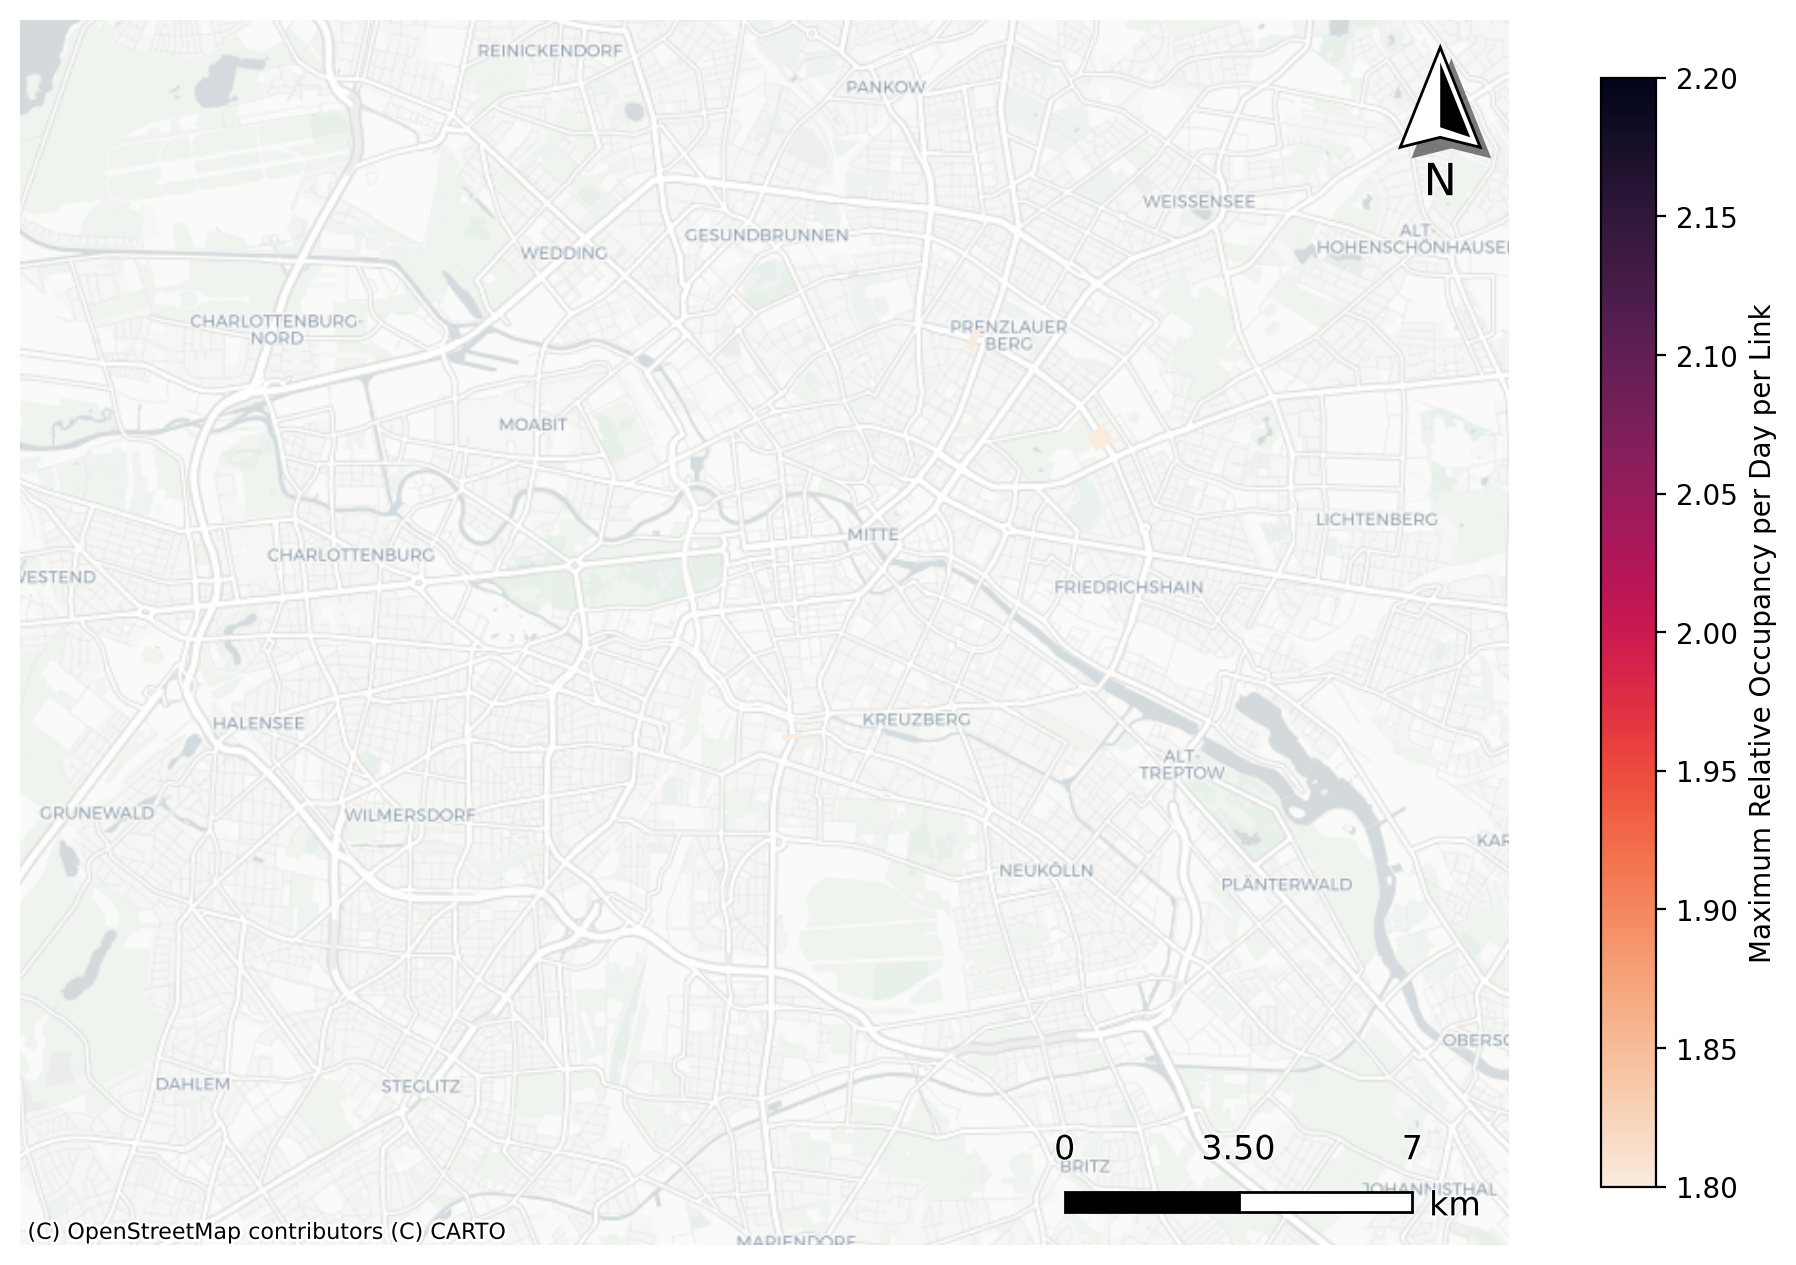

In [53]:

import contextily as ctx
import matplotlib.pyplot as plt

from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_map_utils.core.scale_bar import scale_bar

fig, ax = plt.subplots(figsize=(12, 12))

# vmin = gdf_plot[value_col].min()
# vmax = gdf_plot[value_col].max()
#
# cmap = plt.cm.viridis
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_plot.plot(
    column=value_col,
    ax=ax,
    cmap="rocket_r",
    linewidth=7.5,
    # cmap=cmap,
    # norm=norm,
    legend=True,  # <- important: turn off geopandas legend
    # edgecolor="none",
    legend_kwds={
        "label": "Maximum Relative Occupancy per Day per Link",
        "shrink": 0.6,      # scale height of colorbar
        # "aspect": 20,       # thickness ratio
        # "pad": 0.01,        # spacing to plot
        # "fraction": 0.03,   # width relative to plot
    }
)
#
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # needed for older mpl behavior
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Relative Overshoot")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

north_arrow(
    ax, location="upper right", rotation={"crs": filtered_cost.crs, "reference": "center"}
)
scale_bar(ax, location="lower right", style="boxes", bar={"projection": filtered_cost.crs, "unit": "km"})


ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

title = "max-daily-occupancy"
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()


## Parking Cost per Time Step

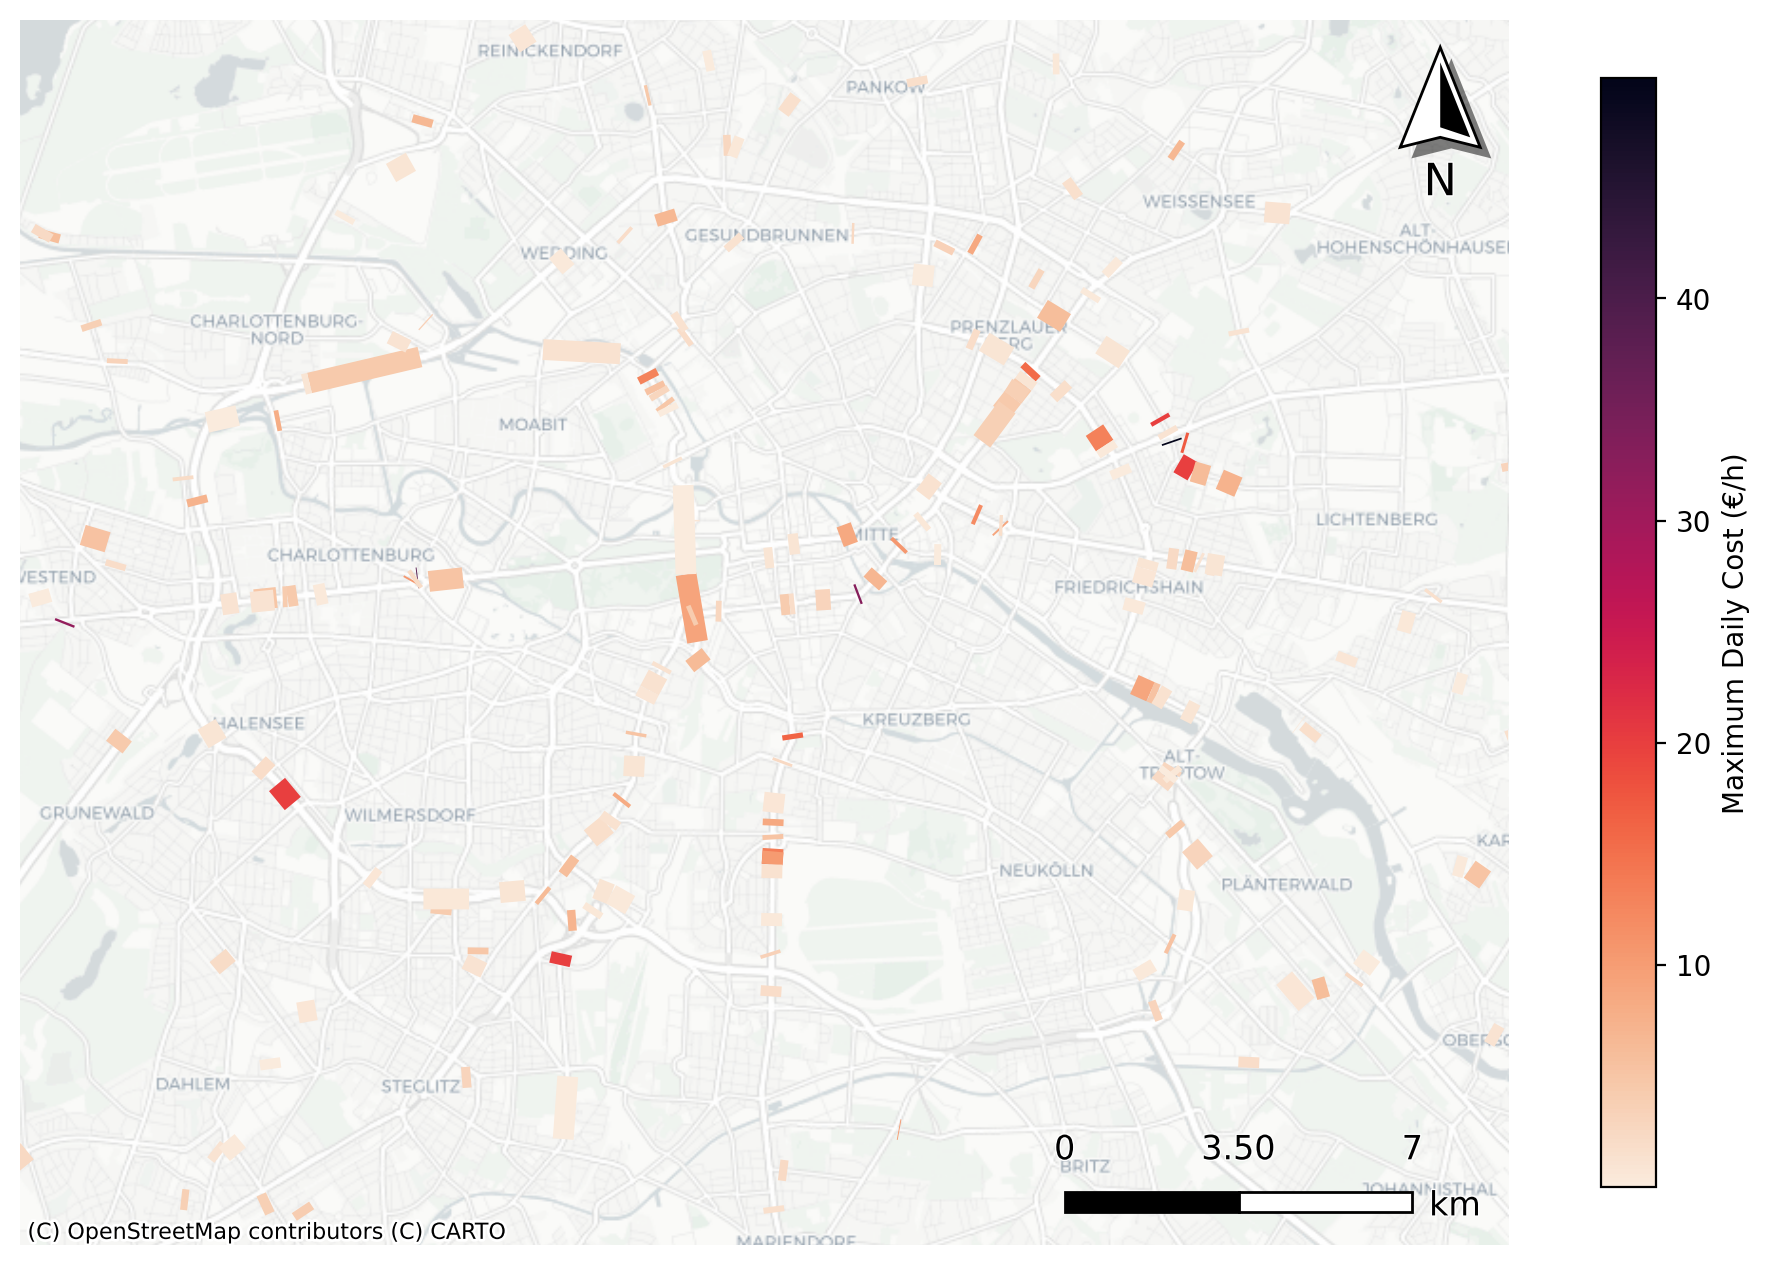

In [54]:
import contextily as ctx
import matplotlib.pyplot as plt

from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_map_utils.core.scale_bar import scale_bar

fig, ax = plt.subplots(figsize=(12, 12))

value_col = "cost"

filtered_cost.plot(
    column=value_col,
    ax=ax,
    cmap="rocket_r",
    # norm=norm,
    legend=True,  # <- important: turn off geopandas legend
    # edgecolor="none",
    linewidth=7.5,
    legend_kwds={
        "label": "Maximum Daily Cost (€/h)",
        "shrink": 0.6,      # scale height of colorbar
        # "aspect": 20,       # thickness ratio
        # "pad": 0.01,        # spacing to plot
        # "fraction": 0.03,   # width relative to plot
    }
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

north_arrow(
    ax, location="upper right", rotation={"crs": filtered_cost.crs, "reference": "center"}
)
scale_bar(ax, location="lower right", style="boxes", bar={"projection": filtered_cost.crs, "unit": "km"})

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

title = "max-daily-cost"
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()


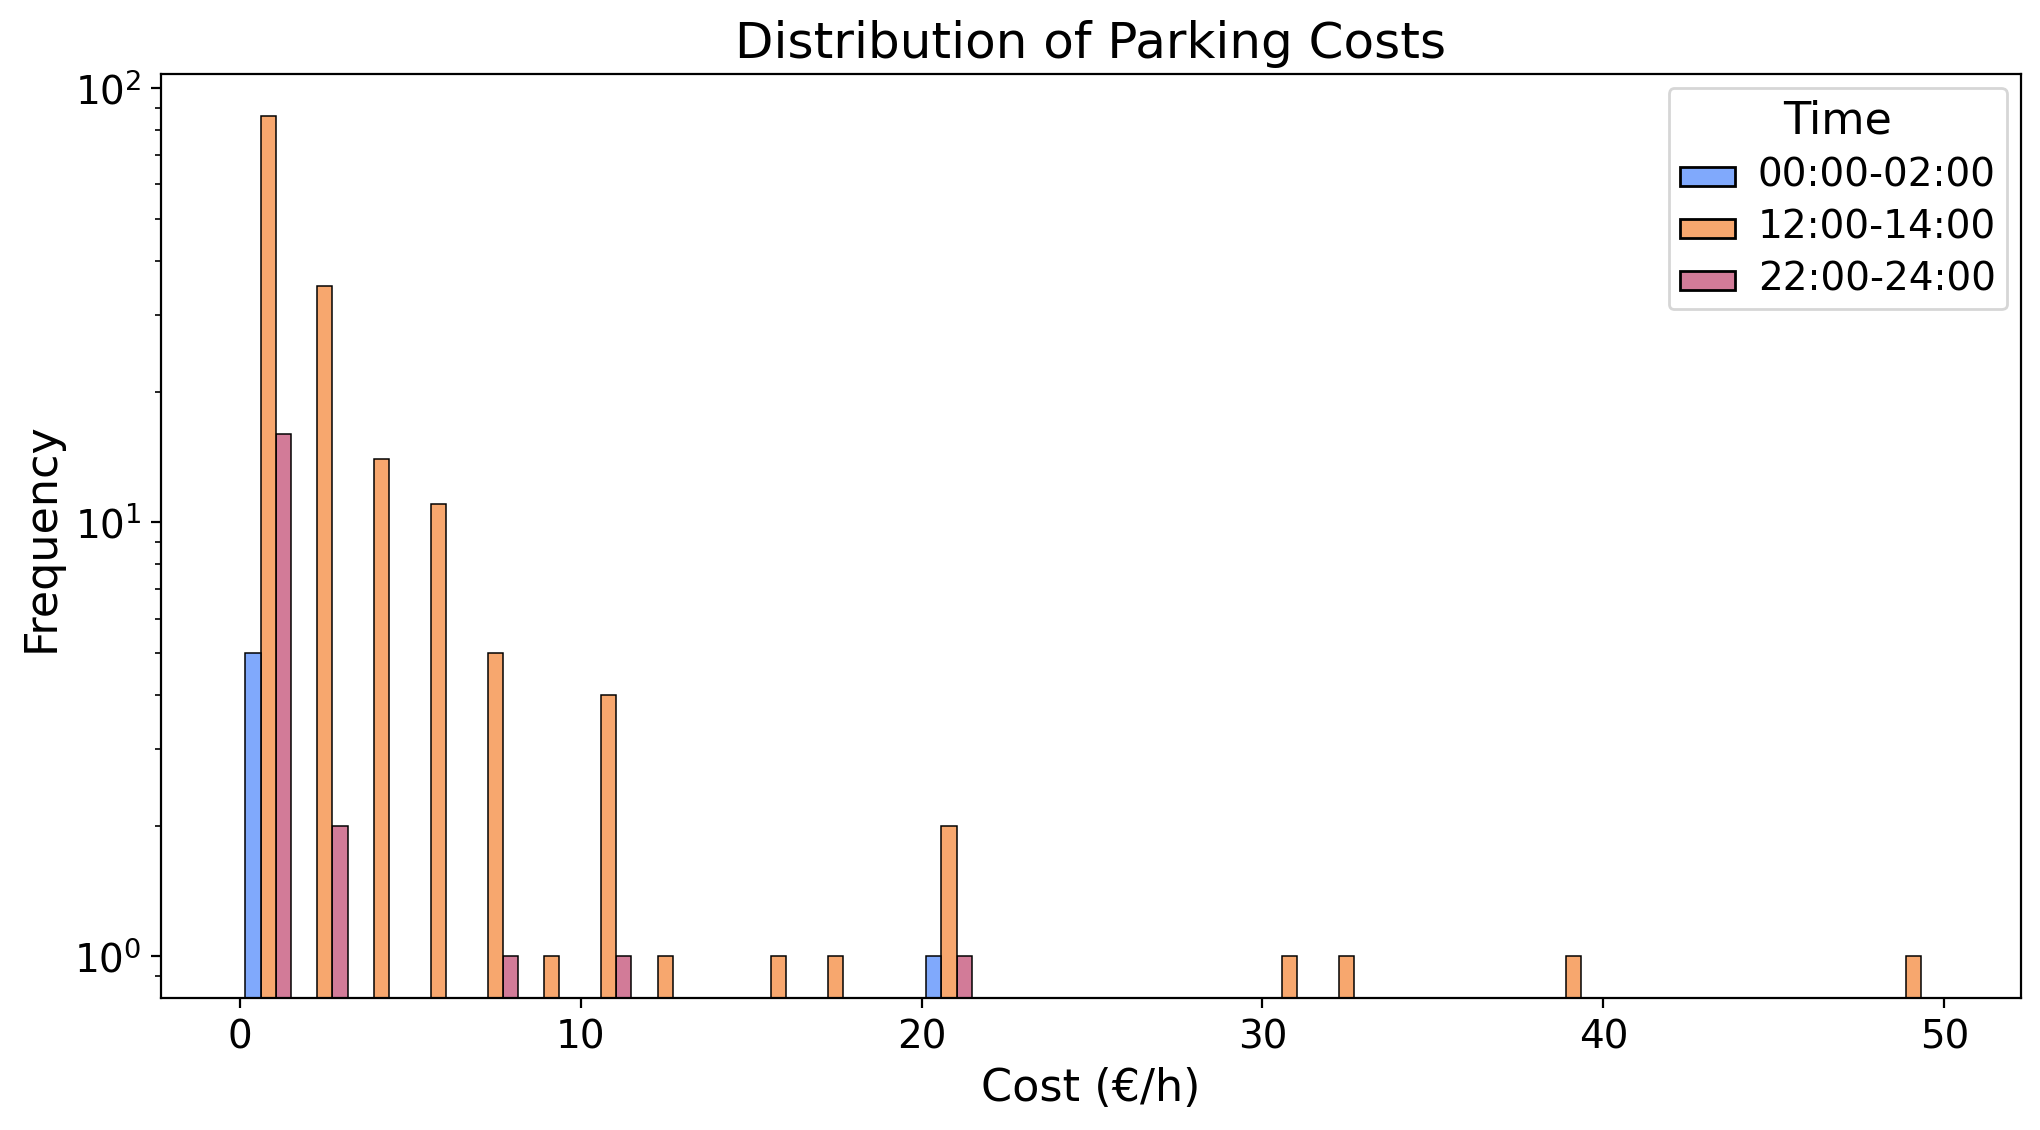

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = cost_df[cost_df["from_time"].isin([0, 12*3600, 22*3600])]
df = df[df["cost"] > 0.0]

mapping = {
    0: "00:00-02:00",
    12*3600: "12:00-14:00",
    22*3600: "22:00-24:00",
}

order = ["00:00-02:00", "12:00-14:00", "22:00-24:00"]

df["time_label"] = df["from_time"].map(mapping)
df["time_label"] = pd.Categorical(
    df["time_label"],
    categories=order,
    ordered=True,
)

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df,
    x="cost",
    hue="time_label",
    bins=30,
    multiple="dodge",
    shrink=0.8,
    common_bins=True,
)

plt.yscale("log")

# Axis labels
plt.xlabel("Cost (€/h)", fontsize=16)
plt.ylabel("Frequency", fontsize=16)

# Title
title = "Distribution of Parking Costs"
plt.title(title, fontsize=18)

# Tick label sizes
ax.tick_params(axis='both', labelsize=14)

# Legend formatting
legend = ax.get_legend()
legend.set_title("Time", prop={"size": 16})

for text in legend.get_texts():
    text.set_fontsize(14)


plt.savefig(
    "./plots/" + title + ".pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

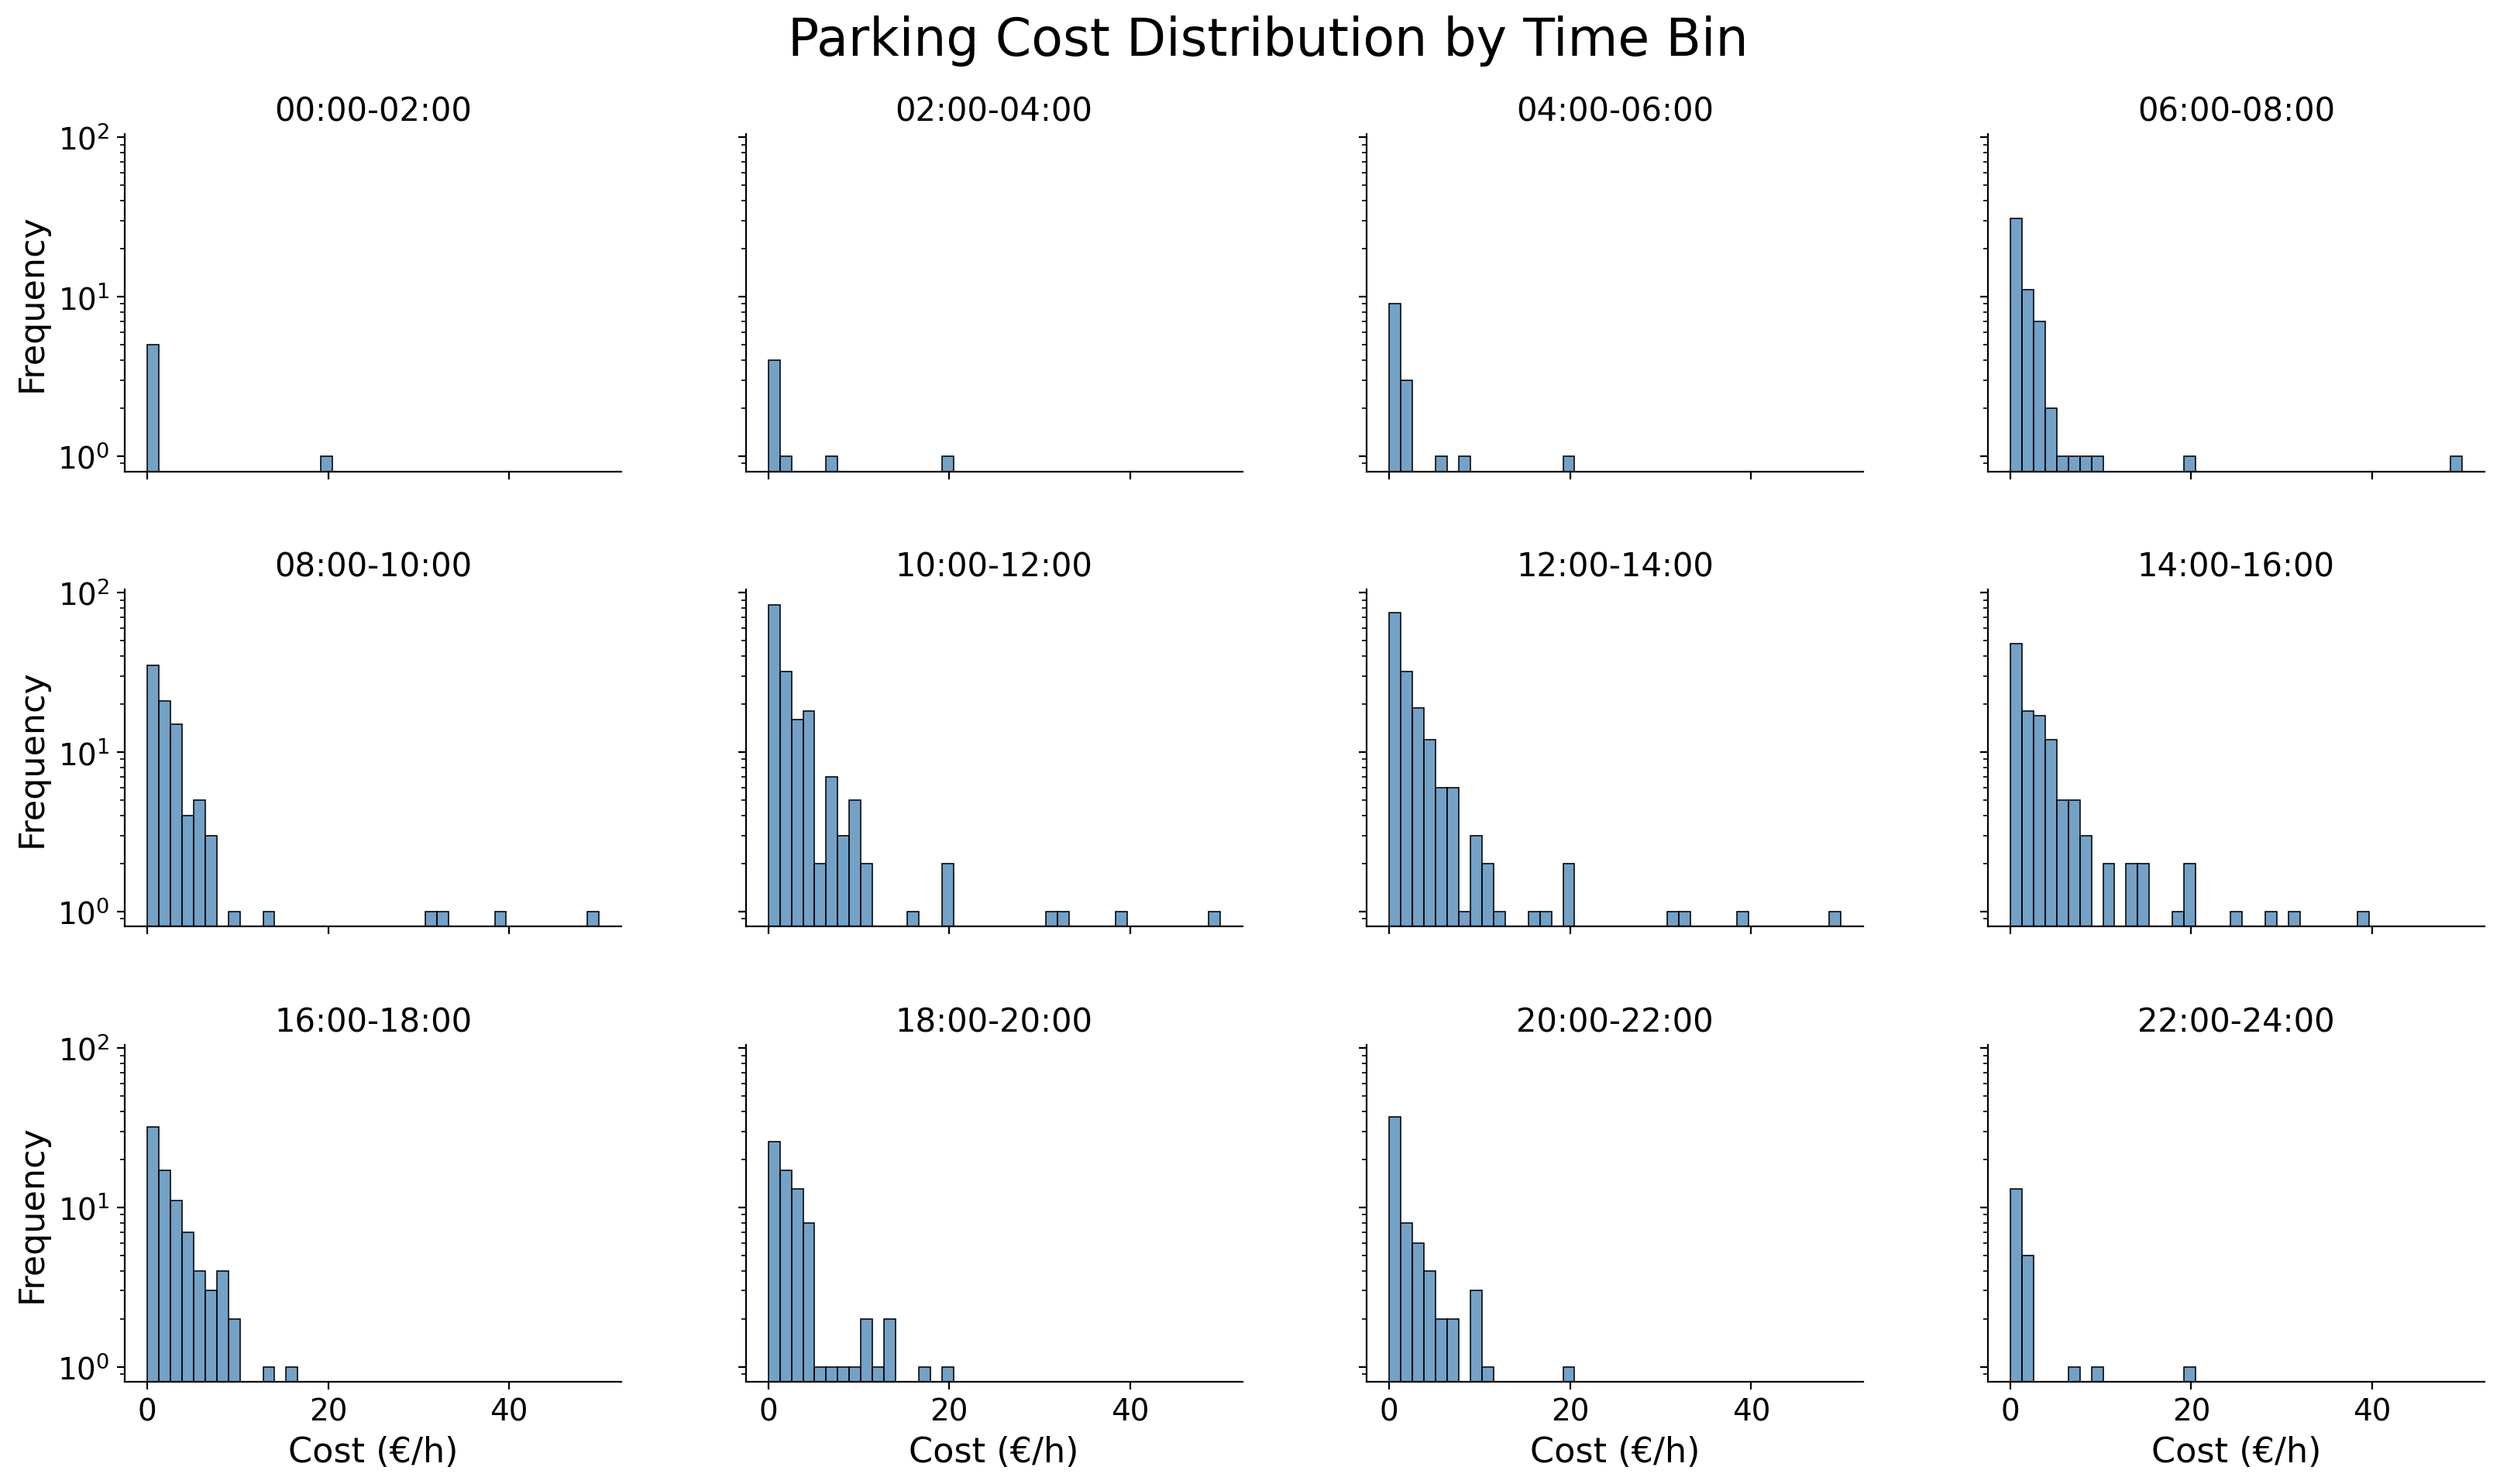

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = cost_df.copy()
df = df[df["cost"] > 0]

mapping = {
    i * 2 * 3600: f"{i*2:02d}:00-{(i+1)*2:02d}:00"
    for i in range(12)
}

order = [
    f"{i*2:02d}:00-{(i+1)*2:02d}:00"
    for i in range(12)
]

df["time_label"] = df["from_time"].map(mapping)
df["time_label"] = pd.Categorical(
    df["time_label"],
    categories=order,
    ordered=True
)

# fixed bin edges for all facets
bins = np.linspace(df["cost"].min(), df["cost"].max(), 40)

g = sns.FacetGrid(
    df,
    col="time_label",
    col_order=order,
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=3.2,
    aspect=1.25
)

g.map_dataframe(
    sns.histplot,
    x="cost",
    bins=bins,
    color="steelblue",
    edgecolor="black"
)

for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlabel("Cost (€/h)", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    ax.set_title(ax.get_title().replace("time_label = ", ""), fontsize=15)

title = "Parking Cost Distribution by Time Bin"
g.fig.suptitle(title, fontsize=24)
g.fig.subplots_adjust(top=0.9, hspace=0.35, wspace=0.25)

plt.savefig(
    "./plots/" + title + "_facet.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

# Recalculation of relative overshoot